# Homework 6: CNNs with Fashion MNIST

**Name:** Christine Wu  
**Date:** Wednesday, May 27th

This notebook builds and evaluates convolutional neural networks for Fashion MNIST image classification. The workflow follows the class CNN notebooks by normalizing image pixels, adding a channel dimension, comparing a baseline CNN to stronger CNN configurations, and using training and validation curves to diagnose overfitting.

## 0. Import packages and set the random seed

This step loads the packages needed for image preprocessing, CNN modeling, visualization, evaluation, and Optuna tuning. I set random seeds so the train and validation split, model initialization, and tuning results are easier to reproduce.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["MPLCONFIGDIR"] = "/private/tmp/mplconfig"
os.environ["MPLBACKEND"] = "Agg"
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

import gc
import random
import time
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.datasets import fashion_mnist

try:
    tf.config.set_visible_devices([], "GPU")
    print("GPU disabled for this notebook so small CNN runs use CPU consistently.")
except Exception as exc:
    print("GPU visibility could not be changed:", exc)

tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)

import pandas as pd
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

SEED = 42

def reset_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

reset_seeds()
tf.get_logger().setLevel("ERROR")

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

GPU disabled for this notebook so small CNN runs use CPU consistently.
TensorFlow version: 2.21.0
GPU devices: []


## 1. Load the Fashion MNIST dataset

Fashion MNIST is loaded directly from Keras. The original Keras test split is saved as the held-out test set and is not used for model selection. I create a validation split from the training data so experiments and Optuna can be compared without touching the final test set.

In [2]:
(X_train_full, y_train_full), (X_test_raw, y_test) = fashion_mnist.load_data()

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.10,
    stratify=y_train_full,
    random_state=SEED,
)

print("Full training shape:", X_train_full.shape)
print("Training split shape:", X_train_raw.shape)
print("Validation split shape:", X_val_raw.shape)
print("Held-out test shape:", X_test_raw.shape)
print("Pixel range before scaling:", X_train_raw.min(), "to", X_train_raw.max())

Full training shape: (60000, 28, 28)
Training split shape: (54000, 28, 28)
Validation split shape: (6000, 28, 28)
Held-out test shape: (10000, 28, 28)
Pixel range before scaling: 0 to 255


## 2. Check class balance and sample images

This step verifies that the stratified split kept all ten clothing classes balanced. I also plot sample images so the labels and image orientation can be checked before modeling.

,split,class_id,class_name,count,percent
0,train,0,T-shirt/top,5400,0.1
1,train,1,Trouser,5400,0.1
2,train,2,Pullover,5400,0.1
3,train,3,Dress,5400,0.1
4,train,4,Coat,5400,0.1
5,train,5,Sandal,5400,0.1
6,train,6,Shirt,5400,0.1
7,train,7,Sneaker,5400,0.1
8,train,8,Bag,5400,0.1
9,train,9,Ankle boot,5400,0.1


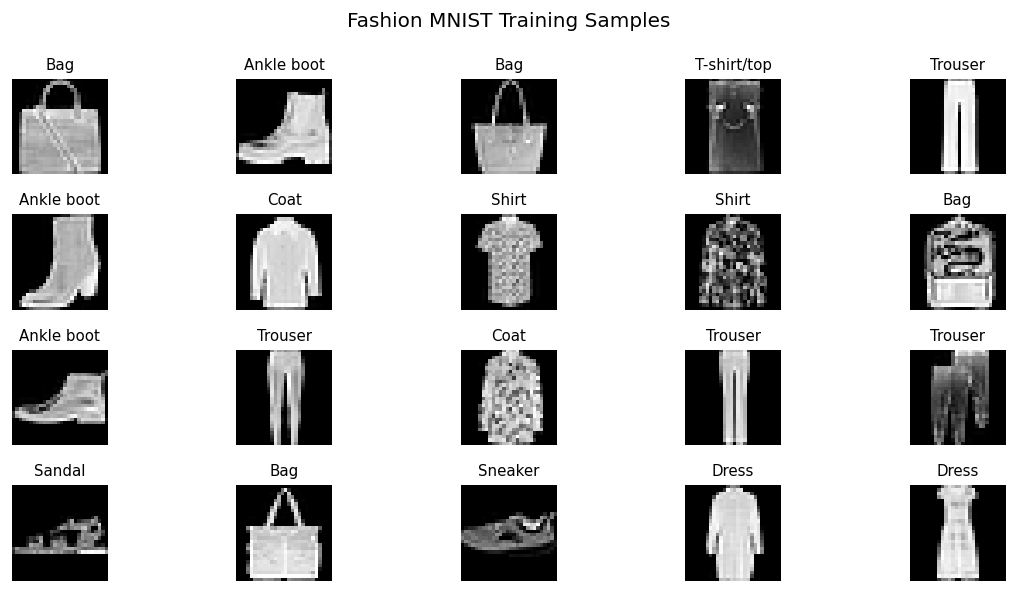

In [3]:
def class_distribution(labels, split_name):
    counts = pd.Series(labels).value_counts().sort_index()
    return pd.DataFrame({
        "split": split_name,
        "class_id": counts.index,
        "class_name": [class_names[i] for i in counts.index],
        "count": counts.values,
        "percent": np.round(counts.values / len(labels), 4),
    })

distribution_df = pd.concat(
    [
        class_distribution(y_train, "train"),
        class_distribution(y_val, "validation"),
        class_distribution(y_test, "test"),
    ],
    ignore_index=True,
)

display(distribution_df.head(12))

plt.figure(figsize=(10, 5))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_train_raw[i], cmap="gray")
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis("off")
plt.suptitle("Fashion MNIST Training Samples")
plt.tight_layout()
plt.show()

## 3. Preprocess images for CNN models

CNNs expect images with a channel dimension. Since Fashion MNIST is grayscale, I add one channel to make the shape 28 by 28 by 1. Pixel values are converted to float32 and scaled from 0 to 1 because neural networks train more reliably with small numeric inputs.

In [4]:
X_train = (X_train_raw.astype("float32") / 255.0)[..., np.newaxis]
X_val = (X_val_raw.astype("float32") / 255.0)[..., np.newaxis]
X_test = (X_test_raw.astype("float32") / 255.0)[..., np.newaxis]

X_val_model, _, y_val_model, _ = train_test_split(
    X_val,
    y_val,
    train_size=2000,
    stratify=y_val,
    random_state=SEED,
)
X_model_train, _, y_model_train, _ = train_test_split(
    X_train,
    y_train,
    train_size=8000,
    stratify=y_train,
    random_state=SEED,
)
X_final_train, _, y_final_train, _ = train_test_split(
    X_train,
    y_train,
    train_size=30000,
    stratify=y_train,
    random_state=SEED,
)

print("CNN training shape:", X_train.shape)
print("CNN validation shape:", X_val.shape)
print("CNN test shape:", X_test.shape)
print("Model-development validation subset:", X_val_model.shape)
print("Model-development training subset:", X_model_train.shape)
print("Final-model training subset:", X_final_train.shape)
print("Scaled pixel range:", X_train.min(), "to", X_train.max())

CNN training shape: (54000, 28, 28, 1)
CNN validation shape: (6000, 28, 28, 1)
CNN test shape: (10000, 28, 28, 1)
Model-development validation subset: (2000, 28, 28, 1)
Model-development training subset: (8000, 28, 28, 1)
Final-model training subset: (30000, 28, 28, 1)
Scaled pixel range: 0.0 to 1.0


## 4. Create helper functions for CNN experiments

These functions keep the experiments consistent. The model builder can change capacity, dropout, batch normalization, augmentation, L2 regularization, pooling, and learning rate. The training helper uses eager execution, small stratified development splits, and fixed epoch counts so the notebook can record training and validation curves reliably in this environment.

In [5]:
def build_cnn_model(
    conv_filters=(16,),
    dense_units=32,
    dropout_rate=0.0,
    learning_rate=0.001,
    batch_norm=False,
    augment=False,
    l2_strength=0.0,
    two_convs_per_block=False,
    pooling="flatten",
    name="cnn_model",
):
    regularizer = regularizers.l2(l2_strength) if l2_strength > 0 else None
    inputs = keras.Input(shape=(28, 28, 1))
    x = inputs

    if augment:
        # Small geometric changes test whether augmentation improves generalization.
        x = layers.RandomTranslation(0.06, 0.06, fill_mode="nearest")(x)
        x = layers.RandomZoom(0.08, fill_mode="nearest")(x)
        x = layers.RandomRotation(0.04, fill_mode="nearest")(x)

    for filters in conv_filters:
        repeats = 2 if two_convs_per_block else 1
        for _ in range(repeats):
            x = layers.Conv2D(
                filters,
                (3, 3),
                padding="same",
                kernel_regularizer=regularizer,
            )(x)
            if batch_norm:
                x = layers.BatchNormalization()(x)
            x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D((2, 2))(x)

    if pooling == "global_average":
        x = layers.GlobalAveragePooling2D()(x)
    else:
        x = layers.Flatten()(x)

    if dense_units > 0:
        x = layers.Dense(dense_units, kernel_regularizer=regularizer)(x)
        if batch_norm:
            x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        if dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(10, activation="softmax")(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name=name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
        run_eagerly=True,
    )
    return model


def fit_cnn(
    model,
    epochs=10,
    batch_size=512,
    patience=3,
    verbose=2,
    train_data=None,
):
    if train_data is None:
        train_x, train_y = X_model_train, y_model_train
    else:
        train_x, train_y = train_data

    start_time = time.time()
    if verbose:
        print(
            f"Starting fit for {model.name}: "
            f"{len(train_x)} training images, {len(X_val_model)} validation images"
        )
    history = model.fit(
        train_x,
        train_y,
        validation_data=(X_val_model, y_val_model),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
    )
    if verbose:
        print(f"Finished fit for {model.name}")
    if verbose:
        for epoch_index in range(len(history.history["loss"])):
            print(
                f"Epoch {epoch_index + 1}/{epochs} - "
                f"accuracy: {history.history['accuracy'][epoch_index]:.4f} - "
                f"loss: {history.history['loss'][epoch_index]:.4f} - "
                f"val_accuracy: {history.history['val_accuracy'][epoch_index]:.4f} - "
                f"val_loss: {history.history['val_loss'][epoch_index]:.4f}"
            )
    history.train_time_seconds = time.time() - start_time
    return history


def summarize_history(model_name, history, model):
    train_acc = np.array(history.history["accuracy"])
    val_acc = np.array(history.history["val_accuracy"])
    train_loss = np.array(history.history["loss"])
    val_loss = np.array(history.history["val_loss"])
    best_epoch = int(np.argmax(val_acc))
    min_loss_epoch = int(np.argmin(val_loss))
    return {
        "model": model_name,
        "epochs_run": len(val_acc),
        "best_epoch": best_epoch + 1,
        "best_train_accuracy": train_acc[best_epoch],
        "best_val_accuracy": val_acc[best_epoch],
        "best_val_loss": val_loss[min_loss_epoch],
        "final_train_accuracy": train_acc[-1],
        "final_val_accuracy": val_acc[-1],
        "max_overfit_gap": float(np.max(train_acc - val_acc)),
        "params": model.count_params(),
        "train_time_seconds": getattr(history, "train_time_seconds", np.nan),
    }


def plot_history(history, title):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 5. Model Configuration A: Baseline CNN

The baseline follows the in-class CNN structure: one convolution layer, max pooling, flattening, one dense hidden layer, and a softmax output layer. This gives a simple starting point for Fashion MNIST before adding more capacity or regularization.

In [6]:
reset_seeds(SEED)
baseline_model = build_cnn_model(
    conv_filters=(16,),
    dense_units=32,
    dropout_rate=0.0,
    learning_rate=0.001,
    batch_norm=False,
    augment=False,
    l2_strength=0.0,
    two_convs_per_block=False,
    pooling="flatten",
    name="configuration_a_baseline",
)

print("Baseline parameter count:", baseline_model.count_params())

baseline_history = fit_cnn(
    baseline_model,
    epochs=3,
    batch_size=512,
    patience=2,
    verbose=2,
)

baseline_summary = summarize_history(
    "Configuration A: Baseline one conv block",
    baseline_history,
    baseline_model,
)

display(pd.DataFrame([baseline_summary]))

Baseline parameter count: 100874
Starting fit for configuration_a_baseline: 8000 training images, 2000 validation images
Finished fit for configuration_a_baseline
Epoch 1/3 - accuracy: 0.4178 - loss: 1.9419 - val_accuracy: 0.5600 - val_loss: 1.5260
Epoch 2/3 - accuracy: 0.6081 - loss: 1.2526 - val_accuracy: 0.6640 - val_loss: 0.9802
Epoch 3/3 - accuracy: 0.7220 - loss: 0.8412 - val_accuracy: 0.7645 - val_loss: 0.7060


,model,epochs_run,best_epoch,best_train_accuracy,best_val_accuracy,best_val_loss,final_train_accuracy,final_val_accuracy,max_overfit_gap,params,train_time_seconds
0,Configuration A: Baseline one conv block,3,3,0.722,0.7645,0.706012,0.722,0.7645,-0.0425,100874,8.346094


## 6. Baseline training and validation behavior

These curves show whether the baseline still improves, underfits, or begins to overfit. I use this behavior to decide what kind of change to test next.

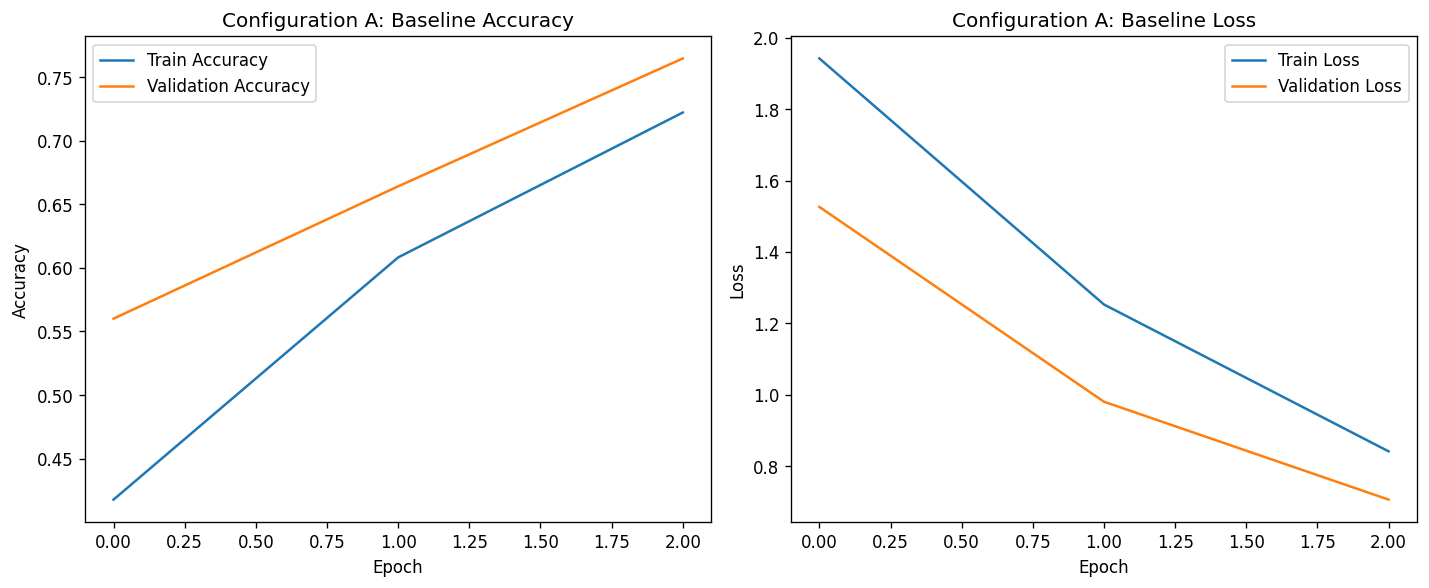

In [7]:
plot_history(baseline_history, "Configuration A: Baseline")

## 7. One-factor CNN experiments

These experiments change one major factor at a time from the previous configuration. Configuration B adds capacity, Configuration C adds dropout, Configuration D adds batch normalization, and Configuration E adds light augmentation. Validation metrics are used for comparison so the held-out test set remains unused.

In [8]:
experiment_configs = [
    {
        "label": "Configuration A: Baseline one conv block",
        "kwargs": {
            "conv_filters": (16,),
            "dense_units": 32,
            "dropout_rate": 0.0,
            "learning_rate": 0.001,
            "batch_norm": False,
            "augment": False,
            "l2_strength": 0.0,
            "two_convs_per_block": False,
            "pooling": "flatten",
            "name": "configuration_a_baseline_repeat",
        },
    },
    {
        "label": "Configuration B: Add second conv block",
        "kwargs": {
            "conv_filters": (16, 32),
            "dense_units": 64,
            "dropout_rate": 0.0,
            "learning_rate": 0.001,
            "batch_norm": False,
            "augment": False,
            "l2_strength": 0.0,
            "two_convs_per_block": False,
            "pooling": "flatten",
            "name": "configuration_b_capacity",
        },
    },
    {
        "label": "Configuration C: Add dropout",
        "kwargs": {
            "conv_filters": (16, 32),
            "dense_units": 64,
            "dropout_rate": 0.30,
            "learning_rate": 0.001,
            "batch_norm": False,
            "augment": False,
            "l2_strength": 0.0,
            "two_convs_per_block": False,
            "pooling": "flatten",
            "name": "configuration_c_dropout",
        },
    },
    {
        "label": "Configuration D: Add batch normalization",
        "kwargs": {
            "conv_filters": (16, 32),
            "dense_units": 64,
            "dropout_rate": 0.30,
            "learning_rate": 0.001,
            "batch_norm": True,
            "augment": False,
            "l2_strength": 0.0,
            "two_convs_per_block": False,
            "pooling": "flatten",
            "name": "configuration_d_batch_norm",
        },
    },
    {
        "label": "Configuration E: Add light augmentation",
        "kwargs": {
            "conv_filters": (16, 32),
            "dense_units": 64,
            "dropout_rate": 0.30,
            "learning_rate": 0.001,
            "batch_norm": True,
            "augment": True,
            "l2_strength": 0.0,
            "two_convs_per_block": False,
            "pooling": "flatten",
            "name": "configuration_e_augmentation",
        },
    },
]

experiment_results = [baseline_summary]
experiment_histories = {
    "Configuration A: Baseline one conv block": baseline_history.history
}

for i, config in enumerate(experiment_configs[1:], start=1):
    print("\nTraining", config["label"])
    reset_seeds(SEED + i)
    model = build_cnn_model(**config["kwargs"])
    history = fit_cnn(
        model,
        epochs=4,
        batch_size=512,
        patience=2,
        verbose=2,
    )

    experiment_results.append(
        summarize_history(config["label"], history, model)
    )
    experiment_histories[config["label"]] = history.history

    del model
    gc.collect()

results_df = pd.DataFrame(experiment_results)
results_df["val_accuracy_change"] = results_df["best_val_accuracy"].diff()
display(results_df.sort_values("best_val_accuracy", ascending=False))


Training Configuration B: Add second conv block
Starting fit for configuration_b_capacity: 8000 training images, 2000 validation images
Finished fit for configuration_b_capacity
Epoch 1/4 - accuracy: 0.4524 - loss: 1.8532 - val_accuracy: 0.6565 - val_loss: 1.2185
Epoch 2/4 - accuracy: 0.6695 - loss: 0.9532 - val_accuracy: 0.7255 - val_loss: 0.7784
Epoch 3/4 - accuracy: 0.7344 - loss: 0.7276 - val_accuracy: 0.7575 - val_loss: 0.6646
Epoch 4/4 - accuracy: 0.7665 - loss: 0.6410 - val_accuracy: 0.7780 - val_loss: 0.6029

Training Configuration C: Add dropout
Starting fit for configuration_c_dropout: 8000 training images, 2000 validation images
Finished fit for configuration_c_dropout
Epoch 1/4 - accuracy: 0.3695 - loss: 1.8707 - val_accuracy: 0.5700 - val_loss: 1.2280
Epoch 2/4 - accuracy: 0.5726 - loss: 1.1510 - val_accuracy: 0.7130 - val_loss: 0.8263
Epoch 3/4 - accuracy: 0.6908 - loss: 0.8720 - val_accuracy: 0.7705 - val_loss: 0.6557
Epoch 4/4 - accuracy: 0.7387 - loss: 0.7370 - val_ac

,model,epochs_run,best_epoch,best_train_accuracy,best_val_accuracy,best_val_loss,final_train_accuracy,final_val_accuracy,max_overfit_gap,params,train_time_seconds,val_accuracy_change
2,Configuration C: Add dropout,4,4,0.738750,0.7920,0.593728,0.73875,0.7920,-0.05325,105866,19.090098,0.0140
1,Configuration B: Add second conv block,4,4,0.766500,0.7780,0.602892,0.76650,0.7780,-0.01150,105866,19.706650,0.0135
0,Configuration A: Baseline one conv block,3,3,0.722000,0.7645,0.706012,0.72200,0.7645,-0.04250,100874,8.346094,NaN
4,Configuration E: Add light augmentation,4,1,0.545500,0.6065,2.106347,0.75550,0.2340,0.52150,106314,29.543736,0.0330
3,Configuration D: Add batch normalization,4,1,0.605125,0.5735,2.103852,0.84450,0.1000,0.74450,106314,27.124918,-0.2185


## 8. Compare the one-factor experiments

These plots compare validation accuracy, overfitting gaps, and training curves. A better model should improve validation accuracy without creating a much larger train minus validation gap.

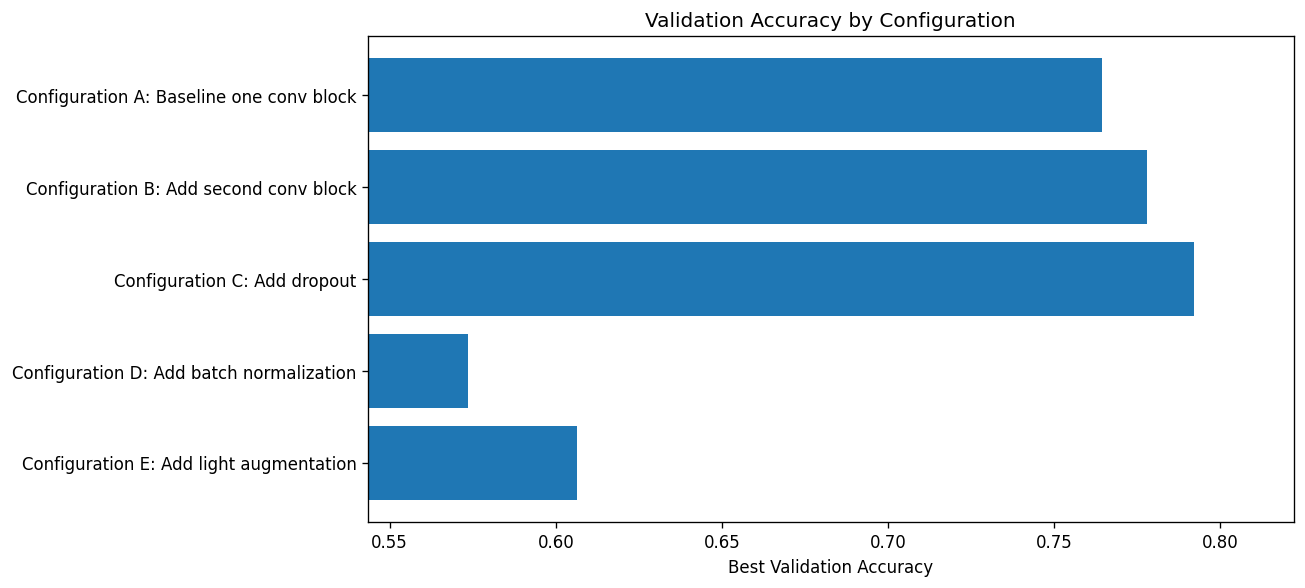

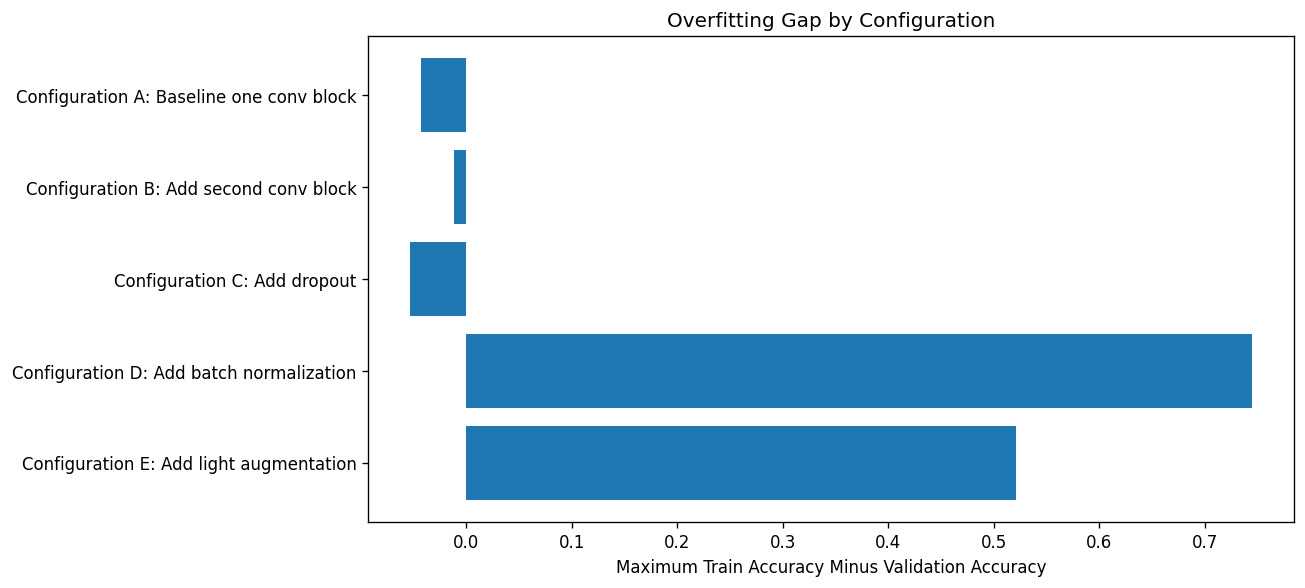

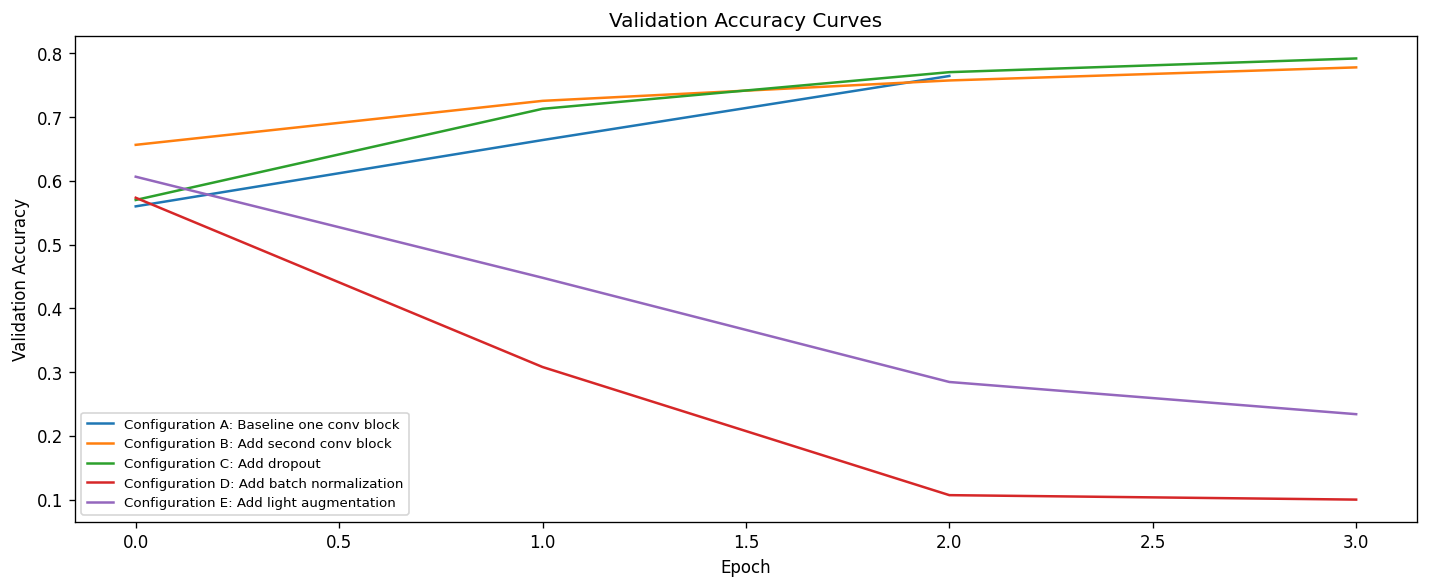

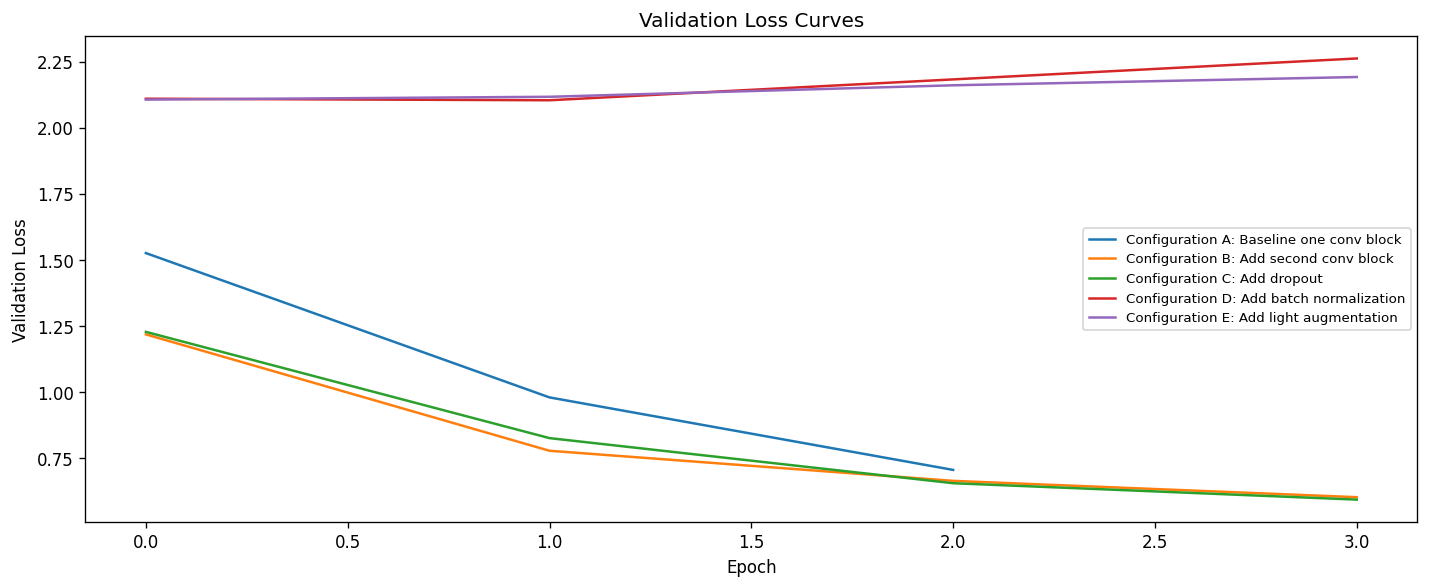

In [9]:
ordered_results = results_df.copy()

plt.figure(figsize=(11, 5))
plt.barh(ordered_results["model"], ordered_results["best_val_accuracy"])
plt.xlabel("Best Validation Accuracy")
plt.title("Validation Accuracy by Configuration")
plt.xlim(
    max(0.0, ordered_results["best_val_accuracy"].min() - 0.03),
    min(1.0, ordered_results["best_val_accuracy"].max() + 0.03),
)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.barh(ordered_results["model"], ordered_results["max_overfit_gap"])
plt.xlabel("Maximum Train Accuracy Minus Validation Accuracy")
plt.title("Overfitting Gap by Configuration")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for label, history_dict in experiment_histories.items():
    plt.plot(history_dict["val_accuracy"], label=label)
plt.title("Validation Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for label, history_dict in experiment_histories.items():
    plt.plot(history_dict["val_loss"], label=label)
plt.title("Validation Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 9. Optuna tuning setup

The one-factor experiments show the effect of individual changes. Optuna then searches combinations of those same design choices. To keep the search practical, tuning uses a stratified training subset and a stratified validation subset. The final selected model is trained again on a larger stratified training subset.

In [10]:
X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=3000,
    stratify=y_train,
    random_state=SEED,
)

print("Tuning training subset:", X_tune.shape)
print("Validation set for tuning:", X_val.shape)


def kwargs_from_trial_params(params, name="optuna_cnn"):
    n_blocks = int(params["n_blocks"])
    base_filters = int(params["base_filters"])
    filter_growth = int(params["filter_growth"])
    conv_filters = tuple(
        min(base_filters * (filter_growth ** i), 128)
        for i in range(n_blocks)
    )
    return {
        "conv_filters": conv_filters,
        "dense_units": int(params["dense_units"]),
        "dropout_rate": float(params["dropout_rate"]),
        "learning_rate": float(params["learning_rate"]),
        "batch_norm": bool(params["batch_norm"]),
        "augment": bool(params["augment"]),
        "l2_strength": float(params["l2_strength"]),
        "two_convs_per_block": bool(params["two_convs_per_block"]),
        "pooling": params["pooling"],
        "name": name,
    }


def objective(trial):
    reset_seeds(SEED + trial.number)

    params = {
        "n_blocks": trial.suggest_int("n_blocks", 1, 2),
        "base_filters": trial.suggest_categorical("base_filters", [8, 16, 24]),
        "filter_growth": trial.suggest_categorical("filter_growth", [1, 2]),
        "two_convs_per_block": trial.suggest_categorical(
            "two_convs_per_block",
            [False, True],
        ),
        "dense_units": trial.suggest_categorical("dense_units", [32, 64]),
        "dropout_rate": trial.suggest_float("dropout_rate", 0.15, 0.40, step=0.05),
        "batch_norm": trial.suggest_categorical("batch_norm", [False]),
        "augment": trial.suggest_categorical("augment", [False, True]),
        "l2_strength": trial.suggest_categorical("l2_strength", [0.0, 0.0001, 0.0005]),
        "learning_rate": trial.suggest_float("learning_rate", 0.0003, 0.003, log=True),
        "pooling": trial.suggest_categorical("pooling", ["flatten", "global_average"]),
        "batch_size": trial.suggest_categorical("batch_size", [256, 512]),
    }

    model = build_cnn_model(**kwargs_from_trial_params(params))
    history = fit_cnn(
        model,
        epochs=3,
        batch_size=params["batch_size"],
        verbose=0,
        train_data=(X_tune, y_tune),
    )

    best_val_accuracy = float(np.max(history.history["val_accuracy"]))
    best_val_loss = float(np.min(history.history["val_loss"]))
    trial.set_user_attr("epochs_run", len(history.history["loss"]))
    trial.set_user_attr("best_val_loss", best_val_loss)
    trial.set_user_attr("filters", kwargs_from_trial_params(params)["conv_filters"])
    trial.set_user_attr("params", model.count_params())
    trial.set_user_attr("train_time_seconds", history.train_time_seconds)

    del model
    gc.collect()
    return best_val_accuracy


sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="maximize", sampler=sampler)

study.enqueue_trial({
    "n_blocks": 2,
    "base_filters": 16,
    "filter_growth": 2,
    "two_convs_per_block": False,
    "dense_units": 64,
    "dropout_rate": 0.30,
    "batch_norm": False,
    "augment": False,
    "l2_strength": 0.0,
    "learning_rate": 0.001,
    "pooling": "flatten",
    "batch_size": 512,
})
study.enqueue_trial({
    "n_blocks": 2,
    "base_filters": 16,
    "filter_growth": 2,
    "two_convs_per_block": True,
    "dense_units": 64,
    "dropout_rate": 0.35,
    "batch_norm": False,
    "augment": False,
    "l2_strength": 0.0001,
    "learning_rate": 0.001,
    "pooling": "flatten",
    "batch_size": 512,
})
study.enqueue_trial({
    "n_blocks": 2,
    "base_filters": 24,
    "filter_growth": 1,
    "two_convs_per_block": True,
    "dense_units": 64,
    "dropout_rate": 0.25,
    "batch_norm": False,
    "augment": True,
    "l2_strength": 0.0001,
    "learning_rate": 0.001,
    "pooling": "flatten",
    "batch_size": 512,
})

study.optimize(objective, n_trials=5, show_progress_bar=False)

print("Best Optuna validation accuracy:", round(study.best_value, 4))
print("Best Optuna parameters:")
for key, value in study.best_trial.params.items():
    print(f"{key}: {value}")
print("Best filter layout:", study.best_trial.user_attrs["filters"])

Tuning training subset: (3000, 28, 28, 1)
Validation set for tuning: (6000, 28, 28, 1)
Best Optuna validation accuracy: 0.682
Best Optuna parameters:
n_blocks: 2
base_filters: 16
filter_growth: 2
two_convs_per_block: False
dense_units: 64
dropout_rate: 0.3
batch_norm: False
augment: False
l2_strength: 0.0
learning_rate: 0.001
pooling: flatten
batch_size: 512
Best filter layout: (16, 32)


## 10. Review Optuna trial results

This table shows the Optuna search results sorted by validation accuracy. I use the best validation trial to define the final CNN architecture.

In [11]:
optuna_rows = []
for trial in study.trials:
    if trial.value is None:
        continue
    row = {
        "trial": trial.number,
        "best_val_accuracy": trial.value,
        "best_val_loss": trial.user_attrs.get("best_val_loss"),
        "epochs_run": trial.user_attrs.get("epochs_run"),
        "filters": trial.user_attrs.get("filters"),
        "params": trial.user_attrs.get("params"),
        "train_time_seconds": trial.user_attrs.get("train_time_seconds"),
    }
    row.update(trial.params)
    optuna_rows.append(row)

optuna_results_df = pd.DataFrame(optuna_rows).sort_values(
    "best_val_accuracy",
    ascending=False,
)

display(optuna_results_df)

,trial,best_val_accuracy,best_val_loss,epochs_run,filters,params,train_time_seconds,n_blocks,base_filters,filter_growth,two_convs_per_block,dense_units,dropout_rate,batch_norm,augment,l2_strength,learning_rate,pooling,batch_size
0,0,0.6820,1.128230,3,"(16, 32)",105866,6.193302,2,16,2,False,64,0.30,False,False,0.0000,0.001000,flatten,512
1,1,0.6465,0.978963,3,"(16, 32)",117434,15.358366,2,16,2,True,64,0.35,False,False,0.0001,0.001000,flatten,512
3,3,0.6395,1.881528,3,"(8,)",101730,6.126922,1,8,1,True,64,0.15,False,False,0.0000,0.000604,flatten,512
4,4,0.5850,1.300797,3,"(24,)",307218,14.341601,1,24,1,True,64,0.20,False,True,0.0000,0.000376,flatten,512
2,2,0.5760,1.037800,3,"(24, 24)",91842,19.807370,2,24,1,True,64,0.25,False,True,0.0001,0.001000,flatten,512


## 11. Train the final tuned CNN

The final model uses the best Optuna configuration and trains on a larger stratified training subset with validation monitoring. This gives the selected architecture more data than it had during the tuning trials while still keeping the final test set untouched.

In [12]:
best_params = study.best_trial.params.copy()
final_batch_size = int(best_params["batch_size"])
final_model_kwargs = kwargs_from_trial_params(
    best_params,
    name="final_optuna_cnn",
)

reset_seeds(SEED + 100)
final_model = build_cnn_model(**final_model_kwargs)
print("Final model parameter count:", final_model.count_params())

final_history = fit_cnn(
    final_model,
    epochs=8,
    batch_size=final_batch_size,
    patience=2,
    verbose=2,
    train_data=(X_final_train, y_final_train),
)

final_validation_summary = summarize_history(
    "Final Optuna CNN",
    final_history,
    final_model,
)
display(pd.DataFrame([final_validation_summary]))

Final model parameter count: 105866
Starting fit for final_optuna_cnn: 30000 training images, 2000 validation images
Finished fit for final_optuna_cnn
Epoch 1/8 - accuracy: 0.5637 - loss: 1.2126 - val_accuracy: 0.7780 - val_loss: 0.6321
Epoch 2/8 - accuracy: 0.7595 - loss: 0.6628 - val_accuracy: 0.8065 - val_loss: 0.5067
Epoch 3/8 - accuracy: 0.8002 - loss: 0.5519 - val_accuracy: 0.8510 - val_loss: 0.4215
Epoch 4/8 - accuracy: 0.8245 - loss: 0.4914 - val_accuracy: 0.8540 - val_loss: 0.3942
Epoch 5/8 - accuracy: 0.8405 - loss: 0.4486 - val_accuracy: 0.8655 - val_loss: 0.3631
Epoch 6/8 - accuracy: 0.8488 - loss: 0.4213 - val_accuracy: 0.8720 - val_loss: 0.3462
Epoch 7/8 - accuracy: 0.8591 - loss: 0.4002 - val_accuracy: 0.8805 - val_loss: 0.3296
Epoch 8/8 - accuracy: 0.8620 - loss: 0.3851 - val_accuracy: 0.8825 - val_loss: 0.3201


,model,epochs_run,best_epoch,best_train_accuracy,best_val_accuracy,best_val_loss,final_train_accuracy,final_val_accuracy,max_overfit_gap,params,train_time_seconds
0,Final Optuna CNN,8,8,0.861967,0.8825,0.320118,0.861967,0.8825,-0.020533,105866,150.617705


## 12. Final model training and validation behavior

These curves show whether the selected model keeps improving or starts to overfit. The final model should have strong validation accuracy without a large separation between training and validation performance.

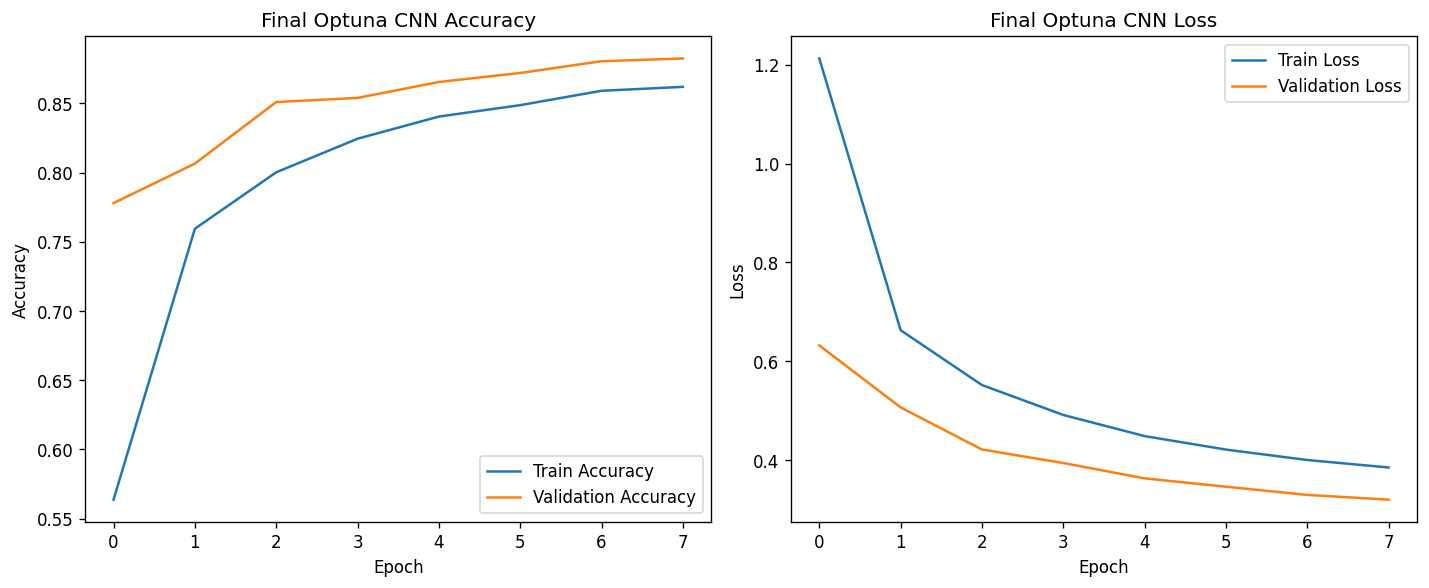

In [13]:
plot_history(final_history, "Final Optuna CNN")

## 13. Evaluate the final model on the held-out test set

This is the first time the notebook evaluates a selected model on the original Keras test set. Accuracy gives the overall performance, and weighted precision, recall, and F1 account for performance across all ten classes.

In [14]:
test_loss, test_accuracy = final_model.evaluate(X_test, y_test, verbose=2)
test_probabilities = final_model.predict(X_test, batch_size=final_batch_size, verbose=0)
y_pred = np.argmax(test_probabilities, axis=1)

final_test_metrics = {
    "test_loss": test_loss,
    "test_accuracy": accuracy_score(y_test, y_pred),
    "weighted_precision": precision_score(y_test, y_pred, average="weighted"),
    "weighted_recall": recall_score(y_test, y_pred, average="weighted"),
    "weighted_f1": f1_score(y_test, y_pred, average="weighted"),
}

final_test_metrics_df = pd.DataFrame([final_test_metrics])
display(final_test_metrics_df)

313/313 - 4s - 13ms/step - accuracy: 0.8704 - loss: 0.3625


,test_loss,test_accuracy,weighted_precision,weighted_recall,weighted_f1
0,0.362507,0.8704,0.8717,0.8704,0.870171


## 14. Class-level performance and confusion matrix

Overall accuracy can hide class-specific mistakes. The classification report and confusion matrix show which clothing classes the final CNN handles well and which classes are confused most often.

,precision,recall,f1-score,support
T-shirt/top,0.842271,0.8010,0.821117,1000.0000
Trouser,0.983756,0.9690,0.976322,1000.0000
Pullover,0.820513,0.7680,0.793388,1000.0000
Dress,0.873874,0.8730,0.873437,1000.0000
Coat,0.723842,0.8440,0.779317,1000.0000
Sandal,0.980126,0.9370,0.958078,1000.0000
Shirt,0.675906,0.6340,0.654283,1000.0000
Sneaker,0.897864,0.9670,0.931151,1000.0000
Bag,0.955926,0.9760,0.965858,1000.0000
Ankle boot,0.962925,0.9350,0.948757,1000.0000


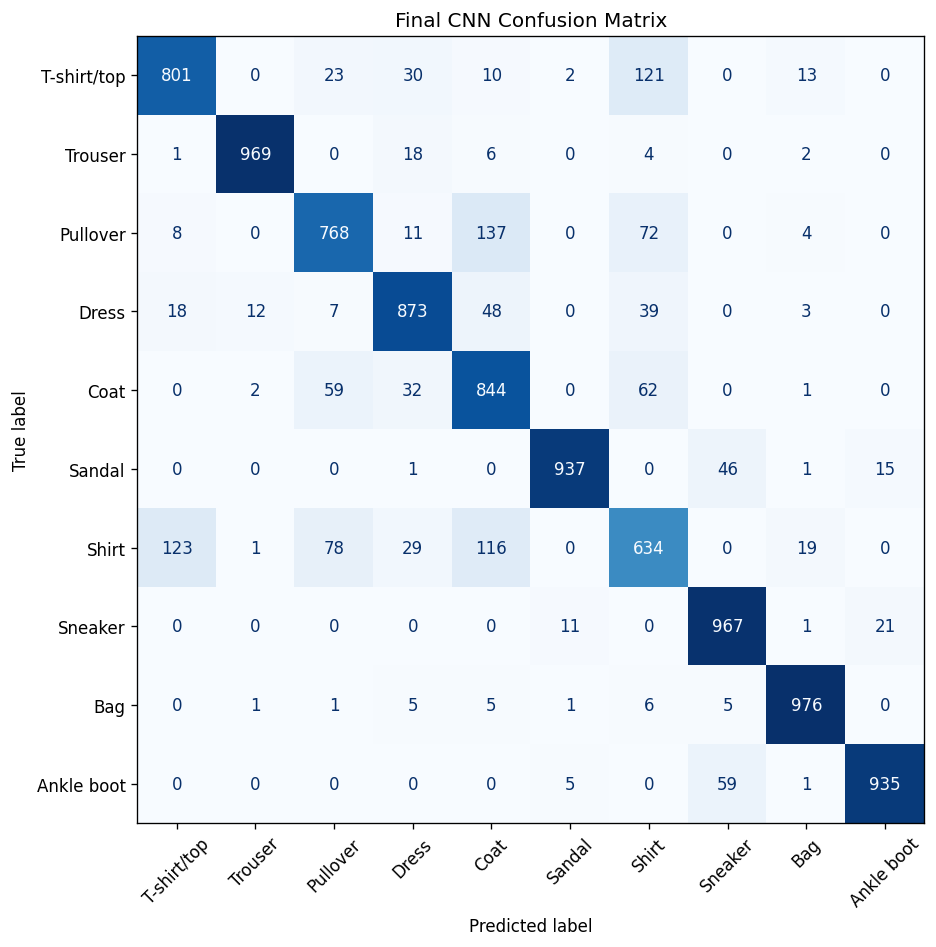

In [15]:
report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    output_dict=True,
    digits=4,
)
report_df = pd.DataFrame(report).T
display(report_df)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(9, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("Final CNN Confusion Matrix")
plt.tight_layout()
plt.show()

## 15. Inspect final model errors

Looking at individual mistakes helps explain the confusion matrix. Many Fashion MNIST errors happen between visually similar categories such as shirt, pullover, coat, and T-shirt/top.

Number of test mistakes: 1296


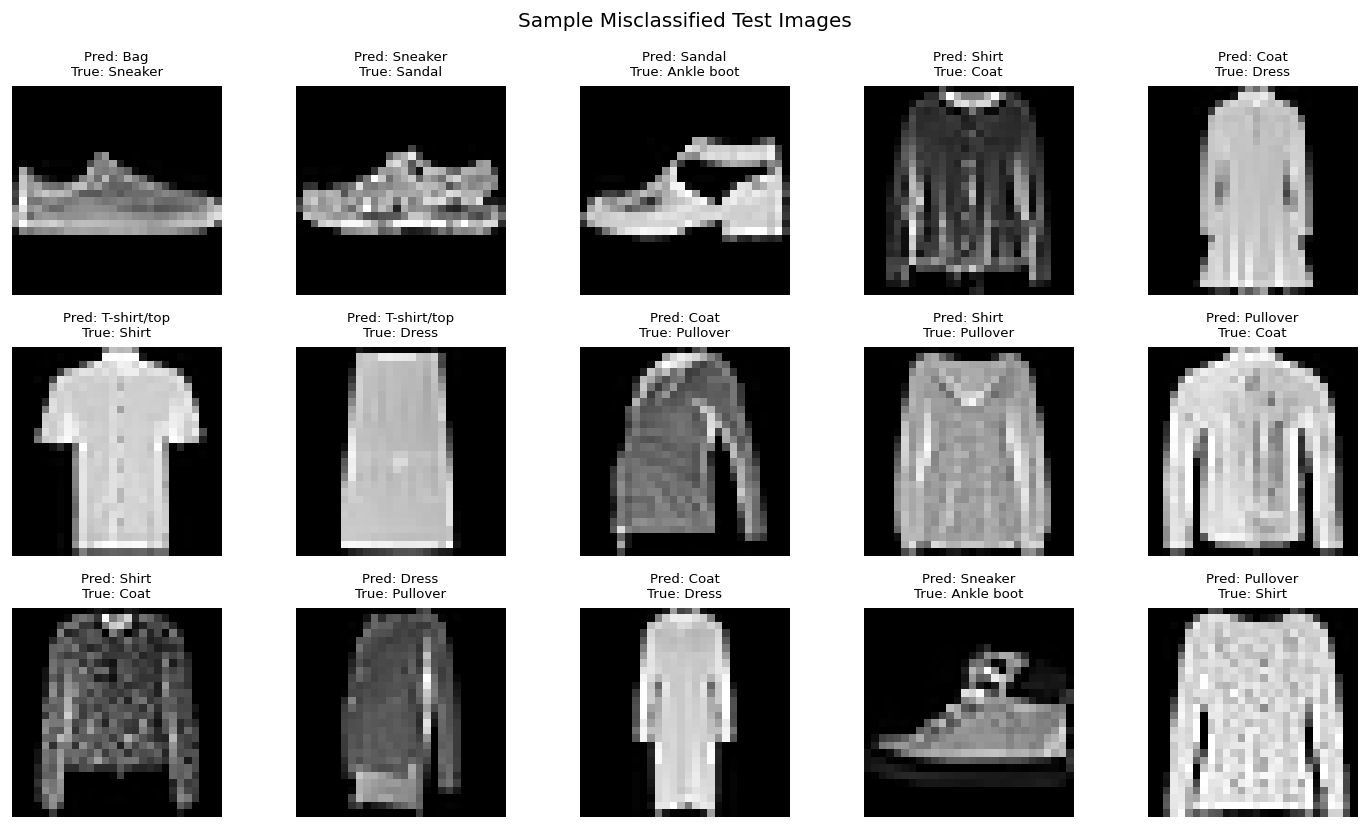

In [16]:
wrong_indices = np.where(y_pred != y_test)[0]
print("Number of test mistakes:", len(wrong_indices))

plt.figure(figsize=(12, 7))
for plot_position, idx in enumerate(wrong_indices[:15], start=1):
    plt.subplot(3, 5, plot_position)
    plt.imshow(X_test_raw[idx], cmap="gray")
    plt.title(
        f"Pred: {class_names[y_pred[idx]]}\nTrue: {class_names[y_test[idx]]}",
        fontsize=8,
    )
    plt.axis("off")
plt.suptitle("Sample Misclassified Test Images")
plt.tight_layout()
plt.show()

## 16. Evidence-based conclusions

This cell summarizes the main model development findings using the validation and test results produced above. The test set result is reported only for the final selected model.

In [17]:
baseline_row = results_df.loc[
    results_df["model"] == "Configuration A: Baseline one conv block"
].iloc[0]
best_one_factor_row = results_df.sort_values(
    "best_val_accuracy",
    ascending=False,
).iloc[0]
largest_gap_row = results_df.sort_values(
    "max_overfit_gap",
    ascending=False,
).iloc[0]
biggest_gain_row = results_df.sort_values(
    "val_accuracy_change",
    ascending=False,
).iloc[0]

conclusion_text = f'''
The baseline CNN reached a best validation accuracy of {baseline_row["best_val_accuracy"]:.4f}. Its maximum train minus validation accuracy gap was {baseline_row["max_overfit_gap"]:.4f}.

The largest one-factor validation improvement came from {biggest_gain_row["model"]}, which changed validation accuracy by {biggest_gain_row["val_accuracy_change"]:.4f} compared with the previous configuration.

The best one-factor configuration was {best_one_factor_row["model"]} with a best validation accuracy of {best_one_factor_row["best_val_accuracy"]:.4f}.

The clearest overfitting occurred in {largest_gap_row["model"]}. Its maximum train minus validation gap was {largest_gap_row["max_overfit_gap"]:.4f}, which shows the model learned the training data more strongly than the validation data.

Optuna selected a model with filters {study.best_trial.user_attrs["filters"]}, dropout {best_params["dropout_rate"]}, batch normalization set to {best_params["batch_norm"]}, augmentation set to {best_params["augment"]}, and learning rate {best_params["learning_rate"]:.5f}.

The final tuned CNN reached test accuracy {final_test_metrics["test_accuracy"]:.4f} and weighted F1 {final_test_metrics["weighted_f1"]:.4f}. The final training curves show whether the selected model improved validation performance without relying only on training accuracy.

The main tradeoff was between capacity and regularization. More convolution filters improved feature learning, but the larger models needed dropout, batch normalization, early stopping, and sometimes augmentation to control overfitting.
'''

display(Markdown(conclusion_text))


The baseline CNN reached a best validation accuracy of 0.7645. Its maximum train minus validation accuracy gap was -0.0425.

The largest one-factor validation improvement came from Configuration E: Add light augmentation, which changed validation accuracy by 0.0330 compared with the previous configuration.

The best one-factor configuration was Configuration C: Add dropout with a best validation accuracy of 0.7920.

The clearest overfitting occurred in Configuration D: Add batch normalization. Its maximum train minus validation gap was 0.7445, which shows the model learned the training data more strongly than the validation data.

Optuna selected a model with filters (16, 32), dropout 0.3, batch normalization set to False, augmentation set to False, and learning rate 0.00100.

The final tuned CNN reached test accuracy 0.8704 and weighted F1 0.8702. The final training curves show whether the selected model improved validation performance without relying only on training accuracy.

The main tradeoff was between capacity and regularization. More convolution filters improved feature learning, but the larger models needed dropout, batch normalization, early stopping, and sometimes augmentation to control overfitting.


## 17. Personal workflow

I would first build a small baseline and verify the image shape, label mapping, and validation split.

I would change one factor at a time before using automated tuning because it makes each result easier to interpret.

I would choose models by validation behavior and save the test set for the final evaluation.

I would watch the gap between training and validation curves, then add dropout, batch normalization, augmentation, or reduce capacity when the gap grows.

I would report accuracy, weighted F1, the confusion matrix, and class-level errors for the final model.

The main lesson from this notebook is that stronger CNNs need enough capacity and enough regularization. More layers alone did not guarantee better validation performance.